# Recipe for identifying and tracking anticyclones using z anomalies at 500hPa using wxlib

#### This recipe is relatively untested. The results should be used with caution and scrutinised before being used in any formal analysis 

Written by: Michael Barnes (ARC CoE for 21st Century Weather) | michael.barnes@monash.edu 

Publication to cite: N/A

In [1]:
import sys
import os
import numpy as np
import xarray as xr
import pandas as pd
import pickle
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

Point path to wxlib and import relavent modules

In [2]:
sys.path.append('/g/data/gb02/mb0427/wxlib/functions/')
from grid import grid_from_xarray
from detect_anticyclones_by_zanoms import detect_anticyclones_by_zanoms
from plotting import plot_tracks_at_time
from utility import generate_datetimes_months
from tracking import update_init_track_lens

Set the output path and list of monthly datetimes for which you want calculations done

In [3]:
running_time=12 #in timesteps
overlap_perc=25
z_anom_threshold=1000
outpath='/g/data/gb02/mb0427/blocking/z500/mean'+str(int(running_time*6))+'/overlap'+str(int(overlap_perc))+'/'
datapath='/g/data/gb02/mb0427/blocking/ERA5/z500_anoms/'
dtlist=generate_datetimes_months(datetime(1981,2,1),datetime(1981,2,1))
first_mn=dtlist[0]
hemisphere='sh'

Load the ERA5 z500 anomaly data. Note: anomalies in this case have been pre-calculated and saved from ERA5. Anomalies are differences from day-of-year means

In [4]:
for imn,mn in enumerate(dtlist):
    print(mn.strftime('%Y%m'))
    
    z_anom_full=xr.open_dataset(datapath+'z500_era5_oper_pl_anom_doy_366_'+mn.strftime('%Y')+'.nc').z_anom
    z_anom=z_anom_full.sel(time=slice(mn,mn+relativedelta(months=1)-relativedelta(hours=1)))
    
    if running_time>0:
        print('Calculating running mean ...')
        mndm1=mn-relativedelta(months=1)
        z_dm1=xr.open_dataset(datapath+'z500_era5_oper_pl_anom_doy_366_'+mndm1.strftime('%Y')+'.nc').z_anom
        z_dm1=z_dm1.sel(time=slice(mn-relativedelta(days=10),mn-relativedelta(hours=1)))
        mndp1=mn+relativedelta(months=1)
        z_dp1=xr.open_dataset(datapath+'z500_era5_oper_pl_anom_doy_366_'+mndp1.strftime('%Y')+'.nc').z_anom
        z_dp1=z_dp1.sel(time=slice(mndp1,mndp1+relativedelta(days=10)))
        
        z_anom=xr.concat([z_dm1,z_anom,z_dp1],dim='time')
        z_anom=z_anom.rolling(time=running_time, center=True).mean()
        z_anom=z_anom.sel(time=slice(mn,mndp1-relativedelta(hours=1)))

        del z_dm1,z_dp1
        
    reg_grid=grid_from_xarray(z_anom)
    if mn==first_mn:
        init_obj_arr=None
        init_df=None
    else:
        init_mn=mn-relativedelta(month=1)
        init_fn='test_anticyc_'+hemisphere+'_'+init_mn.strftime('%Y%m')
        init_obj_arr=xr.open_dataset(outpath+init_fn+'.nc').highs
        init_df=pd.read_pickle(outpath+init_fn+'.pkl')

    high_obj_xr,high_df,grid,z_regrid=\
                detect_anticyclones_by_zanoms(z_anom,reg_grid,hemis=hemisphere,
                    init_df=init_df,init_obj_arr=init_obj_arr,
                    z_anom_threshold=z_anom_threshold,min_overlap_perc=overlap_perc,dT=6,
                    min_area=None,min_living_tstep=None,
                    return_data=True,quiet=False,outpath=outpath,
                    outfilename='test_anticyc_'+hemisphere+'_mean'+str(int(running_time*6))+'_overlap'+str(int(overlap_perc))+'_'+mn.strftime('%Y%m'))
    
    if mn!=first_mn:
        with open(outpath+init_fn+'_updated.pkl', 'wb') as handle:
            pickle.dump(update_init_track_lens(init_df,high_df), handle)

198102
Calculating running mean ...
Detecting blocks ...
   - Regridding data to polar stereographic blocks ...


100%|██████████| 112/112 [08:50<00:00,  4.74s/it]


   - Detecting potential blocks (thresh_id)...
        connect objects over date line
   - Producing the object characteristics ...
            Loop over 477 objects
   - Tracking by overlap ...


/g/data/gb02/mb0427/wxlib/functions/tracking.py:117: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processed_df = indf.groupby("track_id").apply(lambda group: process_group(group.copy(), incoord))


Completed!
        00:11:16.00


In [5]:
xr_to_plot=high_obj_xr*1#xr.concat([init_obj_arr,high_obj_xr],dim='time')
df_to_plot=high_df.copy()#pd.concat((init_df,high_df))

Plot the tracks

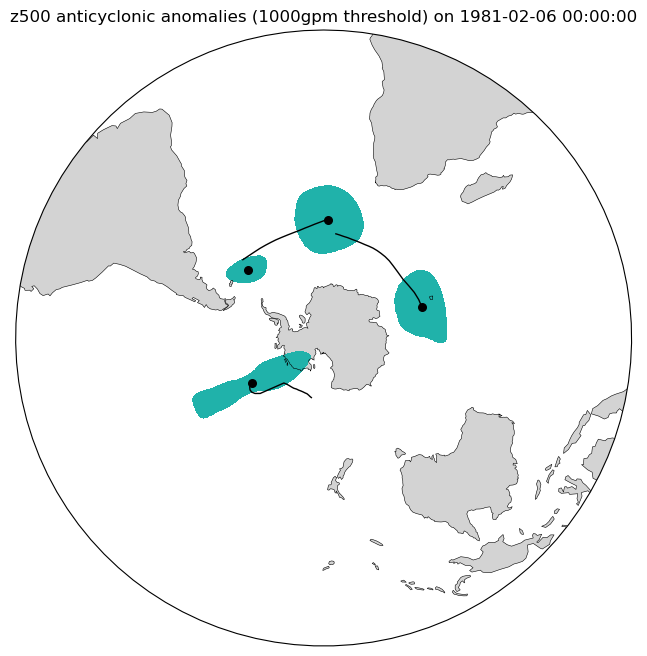

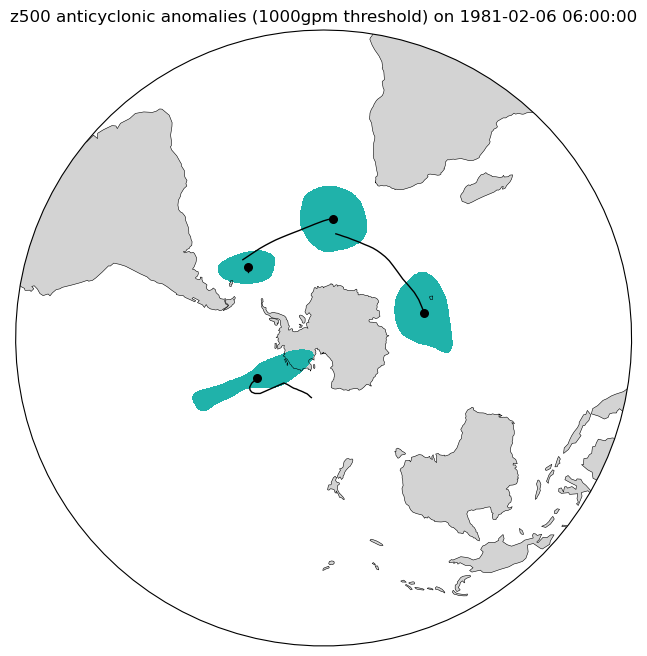

In [6]:
for idt,dt in enumerate(grid['time'][20:22]):
    plot_tracks_at_time(df_to_plot,xr_to_plot,dt,image_desc='z500 anticyclonic anomalies (1000gpm threshold)',
                        outpath=None,outfileprefix=None)#'/g/data/gb02/mb0427/wxlib/test/',outfileprefix='blocking_test')